Image Classification: Car Vs Motorclycles

In [27]:
# importing libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
import random # for displaying random images
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
# Optional: Suppress TensorFlow warnings for cleaner output
import logging
tf.get_logger().setLevel(logging.ERROR)



In [ ]:
# Define paths to your data directories
train_data_dir = '../data/train'
test_data_dir = '../data/test'

# Define image parameters
IMG_HEIGHT = 128 # We'll resize all images to this height
IMG_WIDTH = 128  # We'll resize all images to this width
BATCH_SIZE = 32 # Number of images to process at once during training

class_names = ['Cars', 'Motorcycles'] 

In [4]:
# Load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    labels='inferred',
    label_mode='int', # or 'categorical' for one-hot encoding, 'int' for integer labels
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest', # or 'bicubic'
    batch_size=BATCH_SIZE,
    shuffle=True, # Shuffle for training
    seed=42 # For reproducibility
)

# Load test data (no shuffling for evaluation)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_data_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False, # No shuffling for test set
    seed=42 # For reproducibility
)

# Get the actual class names inferred by TensorFlow to verify
found_class_names = train_ds.class_names
print(f"Found class names in training set: {found_class_names}")
print(f"Number of batches in training set: {len(train_ds)}")
print(f"Number of batches in test set: {len(test_ds)}")

Found 1280 files belonging to 2 classes.


2025-07-29 14:42:17.836477: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 310 files belonging to 2 classes.
Found class names in training set: ['Cars', 'Motorcycles']
Number of batches in training set: 40
Number of batches in test set: 10


2025-07-29 14:45:50.282913: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


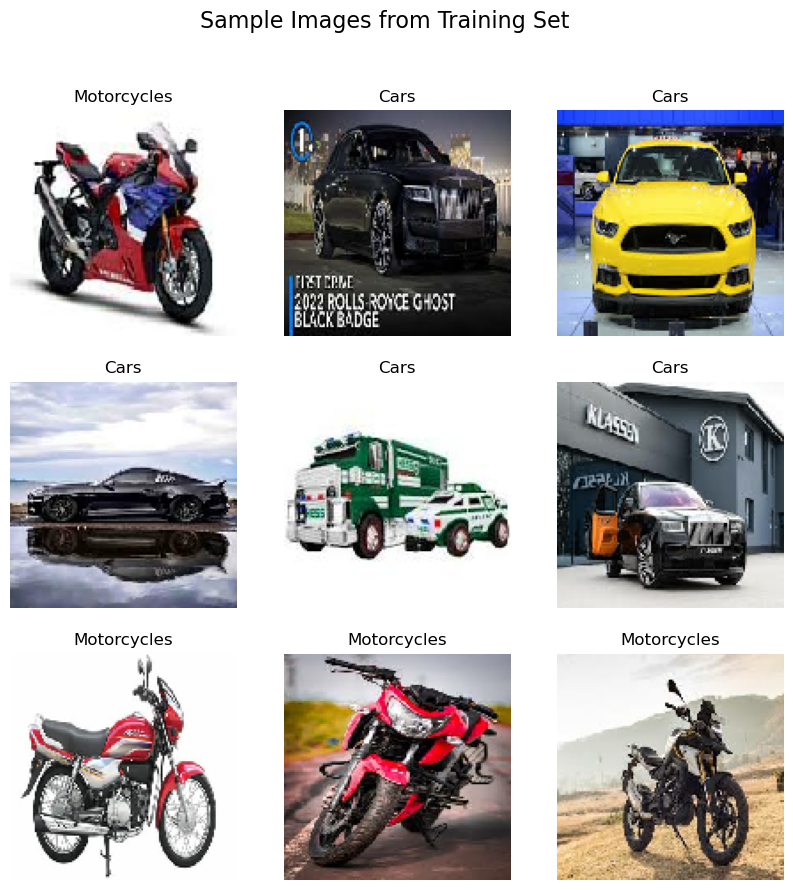


--- Image Details (First Image in Batch) ---
Image shape: (128, 128, 3)
Image data type: <dtype: 'uint8'>
Corresponding label (integer): 1
Corresponding label (class name): Motorcycles


2025-07-29 14:45:51.724078: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
# Display a few sample images from the training set
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # Take one batch from the training dataset
    for i in range(9): # Display 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8")) # Convert tensor to numpy array for displaying
        plt.title(found_class_names[labels[i]]) # Set title with the class name
        plt.axis("off")
plt.suptitle("Sample Images from Training Set", fontsize=16)
plt.show()

print("\n--- Image Details (First Image in Batch) ---")
# Get details of the first image in the first batch
for images, labels in train_ds.take(1):
    first_image = images[0]
    first_label = labels[0]

    print(f"Image shape: {first_image.shape}") # Should be (IMG_HEIGHT, IMG_WIDTH, 3) for color images
    print(f"Image data type: {first_image.dtype}") # Should be tf.float32 or tf.uint8
    print(f"Corresponding label (integer): {first_label.numpy()}")
    print(f"Corresponding label (class name): {found_class_names[first_label.numpy()]}")

In [20]:
import os
import glob

# Determine the absolute path that the script is *actually* looking at.
# This assumes your notebook is in the 'Project_name/notebooks/' directory
# Adjust '../' if your notebook is in a different place relative to 'data/'
abs_test_cars_path = os.path.abspath(os.path.join('..', 'data', 'test', 'Cars'))
abs_test_motorcycles_path = os.path.abspath(os.path.join('..', 'data', 'test', 'Motorcycles'))


print(f"**STEP 1: Verify the exact paths being accessed by the script:**")
print(f"Absolute path for Cars (as seen by script): {abs_test_cars_path}")
print(f"Absolute path for Motorcycles (as seen by script): {abs_test_motorcycles_path}")
print("-" * 50)

# STEP 2: Re-count using os.listdir() for a sanity check (should match previous)
num_cars_listdir = len(os.listdir(abs_test_cars_path))
num_motorcycles_listdir = len(os.listdir(abs_test_motorcycles_path))
print(f"Count using os.listdir() for Cars: {num_cars_listdir}")
print(f"Count using os.listdir() for Motorcycles: {num_motorcycles_listdir}")
print("-" * 50)

# STEP 3: Count using glob.glob() with common image extensions
# This is more robust against non-image files or files without common extensions
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.gif', '*.bmp', '*.webp'] # Added .webp just in case
counted_cars = []
for ext in image_extensions:
    counted_cars.extend(glob.glob(os.path.join(abs_test_cars_path, ext)))
# Use a set to remove duplicates in case glob matches same file with different patterns (e.g., .JPG and .jpg)
counted_cars_unique = list(set(counted_cars))


counted_motorcycles = []
for ext in image_extensions:
    counted_motorcycles.extend(glob.glob(os.path.join(abs_test_motorcycles_path, ext)))
counted_motorcycles_unique = list(set(counted_motorcycles))


num_cars_glob = len(counted_cars_unique)
num_motorcycles_glob = len(counted_motorcycles_unique)

print(f"Count using glob.glob() for Cars (filtering for image extensions): {num_cars_glob}")
print(f"Count using glob.glob() for Motorcycles (filtering for image extensions): {num_motorcycles_glob}")
print(f"Total image files found by glob: {num_cars_glob + num_motorcycles_glob}")

print("\n--- Action Required from You ---")
print("1. **CRITICAL:** Compare the 'Absolute path for Cars (as seen by script)' printed above with the exact path you are looking at in your file explorer. Are they identical?")
print("2. If the paths match, please try these manual checks in your file explorer for the 'Cars' folder:")
print("   a. **Physically count the files.** Select all files and see the count reported by your OS (e.g., Windows Explorer, macOS Finder).")
print("   b. **Check for hidden files.** Ensure your file explorer is set to show hidden files (if applicable on your OS).")
print("   c. **Look for non-image files.** Are there any non-image files (e.g., `.DS_Store`, `Thumbs.db`, `.txt`, `.zip`) or folders mixed in?")
print("   d. **Check file extensions.** Do all 160 files you see have standard image extensions like .jpg, .jpeg, .png, etc.?")

**STEP 1: Verify the exact paths being accessed by the script:**
Absolute path for Cars (as seen by script): /home/chris/Documents/Summative-assignment---MLOP/data/test/Cars
Absolute path for Motorcycles (as seen by script): /home/chris/Documents/Summative-assignment---MLOP/data/test/Motorcycles
--------------------------------------------------
Count using os.listdir() for Cars: 150
Count using os.listdir() for Motorcycles: 160
--------------------------------------------------
Count using glob.glob() for Cars (filtering for image extensions): 150
Count using glob.glob() for Motorcycles (filtering for image extensions): 159
Total image files found by glob: 309

--- Action Required from You ---
1. **CRITICAL:** Compare the 'Absolute path for Cars (as seen by script)' printed above with the exact path you are looking at in your file explorer. Are they identical?
2. If the paths match, please try these manual checks in your file explorer for the 'Cars' folder:
   a. **Physically count th

Training set class distribution: {'Cars': 640, 'Motorcycles': 640} (Total: 1280 images)


2025-07-29 14:52:39.851269: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test set class distribution: {'Cars': 150, 'Motorcycles': 160} (Total: 310 images)


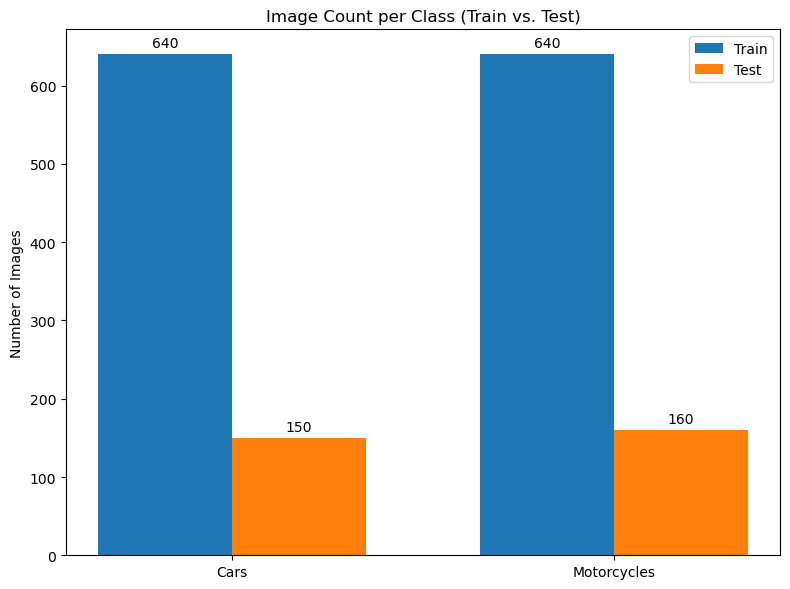

In [6]:
# Function to count images per class
def count_images_in_dataset(dataset, class_names):
    class_counts = {name: 0 for name in class_names}
    num_images = 0
    # Iterate through the dataset to count images
    for _, labels in dataset:
        for label in labels.numpy():
            class_counts[class_names[label]] += 1
        num_images += len(labels.numpy())
    return class_counts, num_images

# Count images in training set
train_counts, total_train_images = count_images_in_dataset(train_ds, found_class_names)
print(f"Training set class distribution: {train_counts} (Total: {total_train_images} images)")

# Count images in test set
test_counts, total_test_images = count_images_in_dataset(test_ds, found_class_names)
print(f"Test set class distribution: {test_counts} (Total: {total_test_images} images)")

# Create a bar chart for class distribution
labels = list(train_counts.keys())
train_values = [train_counts[label] for label in labels]
test_values = [test_counts[label] for label in labels]

x = np.arange(len(labels)) # the label locations
width = 0.35 # the width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, train_values, width, label='Train')
rects2 = ax.bar(x + width/2, test_values, width, label='Test')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Images')
ax.set_title('Image Count per Class (Train vs. Test)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()

In [7]:
# Verify the dimensions of the images in a batch after loading
for images, labels in train_ds.take(1): # Take one batch
    print("\n--- Loaded Image Dimensions ---")
    print(f"Shape of images in a batch: {images.shape}")
    print(f"Number of color channels: {images.shape[-1]} (3 for RGB)")
    print(f"Expected resolution: {IMG_HEIGHT}x{IMG_WIDTH}")

# Interpretation for the report/video (Feature 3: Image Dimensions/Resolution):
print("\n--- Interpretation of Image Dimensions/Resolution ---")
print(f"The images are being loaded and automatically resized to {IMG_HEIGHT}x{IMG_WIDTH} pixels.")
print(f"Each image has {images.shape[-1]} color channels (RGB).")
print("This consistency in size is crucial for feeding images into a Neural Network,")
print("as CNNs typically require fixed-size inputs.")
print("The resolution of 128x128 provides enough detail for the model to distinguish")
print("between cars and motorcycles without being excessively large, which would increase")
print("training time and memory usage.")
print("This step is a vital part of our data preprocessing pipeline to standardize inputs.")


--- Loaded Image Dimensions ---
Shape of images in a batch: (32, 128, 128, 3)
Number of color channels: 3 (3 for RGB)
Expected resolution: 128x128

--- Interpretation of Image Dimensions/Resolution ---
The images are being loaded and automatically resized to 128x128 pixels.
Each image has 3 color channels (RGB).
This consistency in size is crucial for feeding images into a Neural Network,
as CNNs typically require fixed-size inputs.
The resolution of 128x128 provides enough detail for the model to distinguish
between cars and motorcycles without being excessively large, which would increase
training time and memory usage.
This step is a vital part of our data preprocessing pipeline to standardize inputs.


In [8]:
# Optimize dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets prepared for efficient training and evaluation.")

Datasets prepared for efficient training and evaluation.


In [22]:
# Define the CNN model architecture WITH DATA AUGMENTATION
model = keras.Sequential([
    # Input layer: Rescale pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # --- Data Augmentation Layers (Added for Robustness and to prevent overfitting) ---
    layers.RandomFlip("horizontal"), # Randomly flip images horizontally
    layers.RandomRotation(0.1),      # Randomly rotate images by up to 10%
    layers.RandomZoom(0.1),          # Randomly zoom into images by up to 10%
    # ---------------------------------------------------------------------------------

    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 3D output to 1D for the Dense layers
    layers.Flatten(),

    # Dropout Layer (Regularization technique to prevent overfitting)
    layers.Dropout(0.5),

    # Fully Connected (Dense) Layers
    layers.Dense(128, activation='relu'),

    # Output Layer for Binary Classification
    layers.Dense(1, activation='sigmoid')
])

# Display the model summary again to see the new layers
model.summary()

/home/chris/miniconda3/envs/deepclass/lib/python3.10/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:

# Compile the model
model.compile(
    optimizer='adam', # Our chosen optimization technique
    loss='binary_crossentropy', # Appropriate loss for binary classification
    metrics=[
        'accuracy',        # Percentage of correct predictions
        Precision(),       # Precision metric
        Recall(),          # Recall metric
        AUC(name='roc_auc') # ROC AUC metric, useful for binary classification
    ]
)

print("Model compiled successfully with Adam optimizer and specified metrics.")

Model compiled successfully with Adam optimizer and specified metrics.


In [25]:


# Define the number of training epochs
EPOCHS = 50 # We can set a higher number of epochs now, as EarlyStopping will prevent overfitting

# --- Define Callbacks (Training Optimization Techniques) ---

# Early Stopping: Stop training if validation loss doesn't improve for 10 epochs
early_stopping = EarlyStopping(
    monitor='val_loss', # Metric to monitor
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True, # Restore model weights from the epoch with the best monitored value
    verbose=1
)

# Reduce Learning Rate on Plateau: Reduce learning rate if validation loss doesn't improve for 5 epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', # Metric to monitor
    factor=0.2,          # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    patience=5,          # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.00001,      # Lower bound on the learning rate
    verbose=1
)

# List of callbacks to use during training
callbacks = [early_stopping, reduce_lr]

# Train the model
# history object will store the training metrics over epochs
print(f"\nStarting model training for {EPOCHS} epochs with EarlyStopping and ReduceLROnPlateau callbacks...")
history = model.fit(
    train_ds,
    validation_data=test_ds, # Use the test dataset for validation during training
    epochs=EPOCHS,
    callbacks=callbacks # Pass the list of callbacks here
)

print("\nModel training complete.")


Starting model training for 50 epochs with EarlyStopping and ReduceLROnPlateau callbacks...
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 45s 930ms/step - accuracy: 0.5375 - loss: 0.8245 - precision_2: 0.5244 - recall_2: 0.6821 - roc_auc: 0.5438 - val_accuracy: 0.6742 - val_loss: 0.6305 - val_precision_2: 0.6204 - val_recall_2: 0.9500 - val_roc_auc: 0.8787 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 760ms/step - accuracy: 0.7362 - loss: 0.6172 - precision_2: 0.7113 - recall_2: 0.8051 - roc_auc: 0.8061 - val_accuracy: 0.8355 - val_loss: 0.4822 - val_precision_2: 0.7853 - val_recall_2: 0.9375 - val_roc_auc: 0.9089 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 771ms/step - accuracy: 0.8103 - loss: 0.4765 - precision_2: 0.8156 - recall_2: 0.8188 - roc_auc: 0.8886 - val_accuracy: 0.6387 - val_loss: 0.9476 - val_precision_2: 0.5902 - val_recall_2: 0.9812 - val_roc_auc: 0.9272 - learning_rate: 0.0010
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 50s 999ms/step - acc

Keys available in history.history dictionary:
dict_keys(['accuracy', 'loss', 'precision_2', 'recall_2', 'roc_auc', 'val_accuracy', 'val_loss', 'val_precision_2', 'val_recall_2', 'val_roc_auc', 'learning_rate'])
--------------------------------------------------


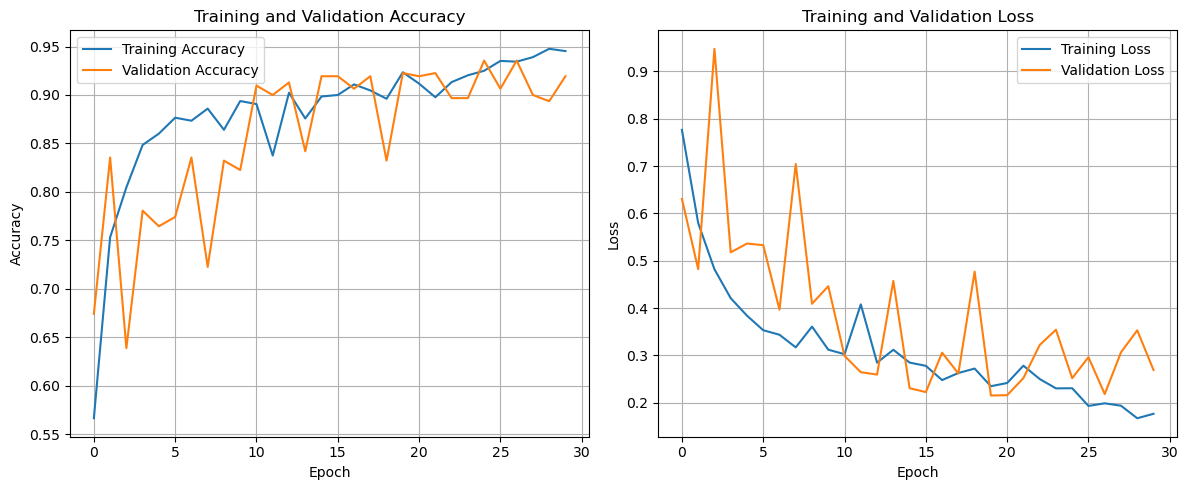

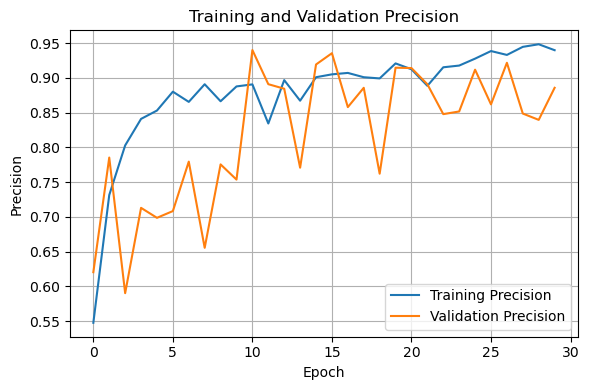

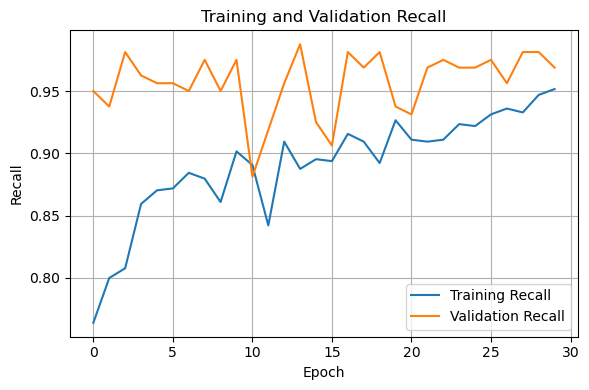

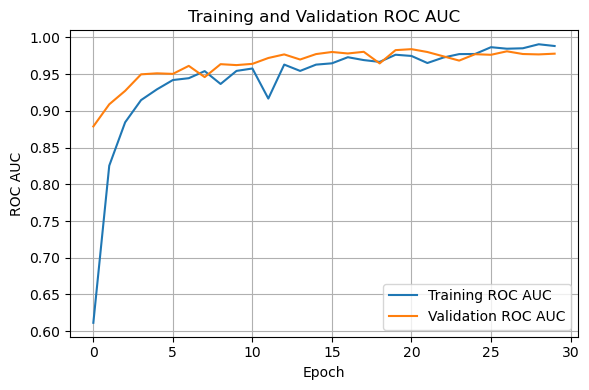

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert history object to a DataFrame for easier plotting
history_df = pd.DataFrame(history.history)

# --- DEBUGGING STEP (already verified, but keeping for reference) ---
print("Keys available in history.history dictionary:")
print(history.history.keys())
print("-" * 50)
# --- End of Debugging Step ---


# Plot training and validation accuracy and loss side-by-side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # This is the first plot in a 1 row, 2 column grid
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2) # This is the second plot in a 1 row, 2 column grid
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# --- Plotting other metrics (Precision, Recall, ROC AUC) ---
# Function to safely get the metric key (already refined, should work with _X suffixes)
def get_metric_key(base_name, keys):
    # Try the exact name first (e.g., 'precision')
    if base_name in keys:
        return base_name
    # Then try with a suffix (e.g., 'precision_1', 'precision_2' etc.)
    for key in keys:
        if key.startswith(base_name + '_'):
            return key
    return None # Metric not found

# Get the actual keys for plotting
precision_key = get_metric_key('precision', history.history.keys())
recall_key = get_metric_key('recall', history.history.keys())
roc_auc_key = get_metric_key('roc_auc', history.history.keys()) # Should be 'roc_auc' due to explicit naming


# Plot Precision if available
if precision_key and f'val_{precision_key}' in history_df.columns:
    plt.figure(figsize=(6, 4))
    plt.plot(history_df[precision_key], label='Training Precision')
    plt.plot(history_df[f'val_{precision_key}'], label='Validation Precision')
    plt.title('Training and Validation Precision')
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: Precision data not found for plotting. Checked for '{precision_key}' and 'val_{precision_key}'. Available keys: {history.history.keys()}")


# Plot Recall if available
if recall_key and f'val_{recall_key}' in history_df.columns:
    plt.figure(figsize=(6, 4))
    plt.plot(history_df[recall_key], label='Training Recall')
    plt.plot(history_df[f'val_{recall_key}'], label='Validation Recall')
    plt.title('Training and Validation Recall')
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: Recall data not found for plotting. Checked for '{recall_key}' and 'val_{recall_key}'. Available keys: {history.history.keys()}")


# Plot ROC AUC if available
if roc_auc_key and f'val_{roc_auc_key}' in history_df.columns:
    plt.figure(figsize=(6, 4))
    plt.plot(history_df[roc_auc_key], label='Training ROC AUC')
    plt.plot(history_df[f'val_{roc_auc_key}'], label='Validation ROC AUC')
    plt.title('Training and Validation ROC AUC')
    plt.xlabel('Epoch')
    plt.ylabel('ROC AUC')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: ROC AUC data not found for plotting. Checked for '{roc_auc_key}' and 'val_{roc_auc_key}'. Available keys: {history.history.keys()}")


--- Model Evaluation on Test Set ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - accuracy: 0.9163 - loss: 0.2322 - precision_2: 0.5084 - recall_2: 0.5999 - roc_auc: 0.6261      
Test Loss: 0.2154
Test Accuracy: 0.9226
Test Precision: 0.9146
Test Recall: 0.9375
Test ROC AUC: 0.9826

--- Generating Predictions for Test Set ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step

--- Classification Report ---
              precision    recall  f1-score   support

        Cars       0.93      0.91      0.92       150
 Motorcycles       0.91      0.94      0.93       160

    accuracy                           0.92       310
   macro avg       0.92      0.92 

2025-07-30 21:47:12.083653: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


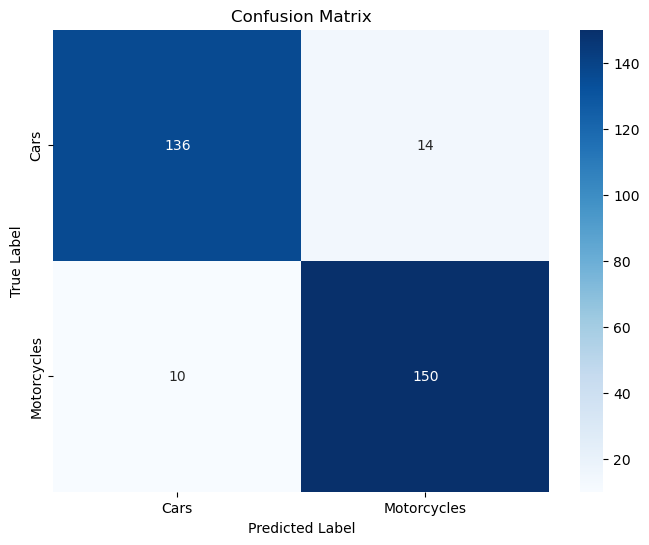


Model evaluation complete. Classification Report and Confusion Matrix generated.


In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # For nicer plots of confusion matrix

# 1. Evaluate the model on the test dataset
print("\n--- Model Evaluation on Test Set ---")
test_loss, test_accuracy, test_precision, test_recall, test_roc_auc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test ROC AUC: {test_roc_auc:.4f}")

# 2. Get predictions for the test set to generate Classification Report and Confusion Matrix
print("\n--- Generating Predictions for Test Set ---")
# Get true labels and predicted probabilities for the test set
test_labels = []
test_predictions_raw = []

for images, labels in test_ds:
    test_labels.append(labels.numpy())
    test_predictions_raw.append(model.predict(images))

test_labels = np.concatenate(test_labels)
test_predictions_raw = np.concatenate(test_predictions_raw)

# Convert probabilities to binary predictions (0 or 1) using a threshold (e.g., 0.5)
test_predictions_binary = (test_predictions_raw > 0.5).astype(int)

# 3. Generate Classification Report
print("\n--- Classification Report ---")
# found_class_names should be ['Cars', 'Motorcycles'] or ['Cars', 'Bikes'] depending on your choice
print(classification_report(test_labels, test_predictions_binary, target_names=found_class_names))

# 4. Generate and Plot Confusion Matrix (The one you reminded me about!)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(test_labels, test_predictions_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=found_class_names, yticklabels=found_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\nModel evaluation complete. Classification Report and Confusion Matrix generated.")

In [39]:
import os

# Define the path where your model will be saved
# We will save it as 'vehicle_classifier_model.keras' inside the 'models/' directory
model_save_path = '../models/vehicle_classifier_model.keras'

# Ensure the 'models/' directory exists
# The os.path.dirname gets the directory part of the path, so it creates 'models/'
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# Save the entire trained model (architecture, weights, and optimizer state)
# This will create a single file: vehicle_classifier_model.keras
model.save(model_save_path)

print(f"\nSUCCESS:  model has been saved to: {model_save_path}")
# Note: The model is saved in the Keras format, which is compatible with TensorFlow 2.x


SUCCESS:  model has been saved to: ../models/vehicle_classifier_model.keras
